# MVP-1 — Baseline CNN + Batch Probe + Fusion-Readiness

**Objetivo:** Obtener los primeros números defendibles del encoder visual.

| Paso | Qué produce | Criterio PIDA |
|------|------------|---------------|
| Baseline CNN | MAE + Spearman por fold | Spearman ≥ 0.6, MAE ≤ 6 PDL ó ≥25% mejora vs trivial |
| Batch probe | AUC predicción fase/magnificación | Cercano a azar (< 0.65 ideal) |
| Fusion-readiness | Corr(z_img, telómero/mtDNA) | > 0 y significativa |

**Hardware:** Mac mini MPS (primario) / Colab T4 (respaldo)

---

## SECCIÓN 0 — CONFIG
Ajustar **solo estas variables** antes de correr.

In [34]:
import os

# ============================================================
# >>> AJUSTAR ESTAS 4 RUTAS <<<
# ============================================================
MANIFEST_PATH = "/Users/JCB/Documentos/Proyecto Integrador/data/manifests/manifest_mvp1_finetune_20260319_153838.csv"
CSV_CENTRAL   = "/Users/JCB/Documentos/Proyecto Integrador/data/Lifespan_Study_Data.csv"
IMAGE_ROOT    = "/Volumes/SanDisk SSD 1TB/Storage/Data/Cellular_Lifespan_Study_Brightfield_Images"
OUTPUT_DIR    = "/Users/JCB/Documentos/Proyecto Integrador/results/mvp1_baseline"

# ============================================================
# COLUMNAS DEL MANIFEST — ajustar si los nombres difieren
# ============================================================
COL_IMG_PATH     = "img_path"        # ruta a la imagen (relativa o absoluta)
COL_PDL_NORM     = "pdl_norm"          # PDL normalizado [0,1] intra cell_line
COL_PDL_RAW      = "pdl"               # PDL crudo (si existe; si no, se ignora)
COL_FOLD         = "fold"              # 0, 1, 2
COL_CELL_LINE    = "cell_line"
COL_STUDY_PART   = "study_part"        # fase 1-5 (para batch probe)
COL_MAGNIFICATION = "magnification"    # "10x" / "20x" (para batch probe)
COL_SAMPLE_ID    = "sample_id"         # para join con CSV central

# Columnas del CSV central para fusion-readiness (se buscan automáticamente)
# Si no las encuentra, las imprime y tú ajustas aquí:
COL_TELOMERE = None   # se autodetecta; o pon "Telomere.Length" etc.
COL_MTDNA    = None   # se autodetecta; o pon "mtDNA.copy.number" etc.

# ============================================================
# HIPERPARÁMETROS
# ============================================================
BATCH_SIZE    = 16
EPOCHS        = 30
PATIENCE      = 7       # early stopping
LR_HEAD       = 1e-3
WEIGHT_DECAY  = 1e-4
EMBEDDING_DIM = 256
IMG_SIZE      = 224
SEED          = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✅ Config cargada. Output → {OUTPUT_DIR}")

✅ Config cargada. Output → /Users/JCB/Documentos/Proyecto Integrador/results/mvp1_baseline


## SECCIÓN 1 — IMPORTS

In [35]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime
import json
import hashlib

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

from scipy.stats import spearmanr, pearsonr
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.preprocessing import LabelEncoder

from PIL import Image

# Reproducibilidad
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Detectar device
if torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
    print("🖥  Device: Apple MPS")
elif torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    print(f"🖥  Device: CUDA — {torch.cuda.get_device_name(0)}")
else:
    DEVICE = torch.device("cpu")
    print("🖥  Device: CPU (va a ser lento)")

🖥  Device: Apple MPS


## SECCIÓN 2 — CARGAR Y VALIDAR MANIFEST

In [36]:
df = pd.read_csv(MANIFEST_PATH)
print(f"Manifest cargado: {df.shape[0]} filas × {df.shape[1]} columnas")

# --- Validar columnas requeridas ---
required = [COL_IMG_PATH, COL_PDL_NORM, COL_FOLD, COL_CELL_LINE]
missing = [c for c in required if c not in df.columns]
if missing:
    print(f"⛔ Columnas faltantes: {missing}")
    print(f"   Columnas disponibles:\n   {sorted(df.columns.tolist())}")
    raise KeyError(f"Ajusta los nombres de columna en CONFIG. Faltan: {missing}")

# --- Resolver rutas de imagen ---
# Si image_path no es absoluta, prepend IMAGE_ROOT
sample_path = df[COL_IMG_PATH].iloc[0]
if not os.path.isabs(sample_path):
    df["_img_abs"] = df[COL_IMG_PATH].apply(lambda p: os.path.join(IMAGE_ROOT, p))
    print(f"   Rutas relativas detectadas → prefijando IMAGE_ROOT")
else:
    df["_img_abs"] = df[COL_IMG_PATH]
    print(f"   Rutas absolutas detectadas")

# --- Verificar que las imágenes existen ---
exists_mask = df["_img_abs"].apply(os.path.exists)
n_missing_imgs = (~exists_mask).sum()
if n_missing_imgs > 0:
    print(f"⚠️  {n_missing_imgs}/{len(df)} imágenes no encontradas en disco.")
    print(f"   Ejemplo: {df.loc[~exists_mask, '_img_abs'].iloc[0]}")
    print(f"   → Filtrando solo imágenes existentes")
    df = df[exists_mask].reset_index(drop=True)
else:
    print(f"✅ Todas las {len(df)} imágenes verificadas en disco")

# ============================================================
# FILTRO: solo 10x — eliminar confounder de magnificación
# ============================================================
n_antes = len(df)
df = df[df[COL_MAGNIFICATION].astype(str) == "10"].reset_index(drop=True)
print(f"🔬 Filtro 10x: {n_antes} → {len(df)} imágenes ({n_antes - len(df)} descartadas)")


# --- Stats rápidas ---
print(f"\n📊 Resumen:")
print(f"   Imágenes: {len(df)}")
print(f"   Cell lines: {sorted(df[COL_CELL_LINE].unique())}")
print(f"   Folds: {df[COL_FOLD].value_counts().sort_index().to_dict()}")
print(f"   PDL norm: [{df[COL_PDL_NORM].min():.3f}, {df[COL_PDL_NORM].max():.3f}]")
if COL_PDL_RAW in df.columns:
    print(f"   PDL raw:  [{df[COL_PDL_RAW].min():.1f}, {df[COL_PDL_RAW].max():.1f}]")

Manifest cargado: 763 filas × 131 columnas
   Rutas absolutas detectadas
✅ Todas las 763 imágenes verificadas en disco
🔬 Filtro 10x: 763 → 393 imágenes (370 descartadas)

📊 Resumen:
   Imágenes: 393
   Cell lines: ['hFB1', 'hFB11', 'hFB12', 'hFB13', 'hFB14', 'hFB2']
   Folds: {0.0: 127, 1.0: 217, 2.0: 49}
   PDL norm: [0.047, 1.000]
   PDL raw:  [2.8, 80.8]


/var/folders/fy/k8jygkfn6hd63_wrlzhk82c40000gp/T/ipykernel_42328/3201183054.py:19: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["_img_abs"] = df[COL_IMG_PATH]


## SECCIÓN 3 — DATASET

In [37]:
class BrightfieldDataset(Dataset):
    """Dataset de imágenes brightfield con PDL normalizado como target."""

    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["_img_abs"])

        # Brightfield puede ser grayscale → convertir a RGB para ResNet
        if img.mode != "RGB":
            img = img.convert("RGB")

        if self.transform:
            img = self.transform(img)

        pdl = torch.tensor(row[COL_PDL_NORM], dtype=torch.float32)
        return img, pdl


# Transforms
train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],   # ImageNet stats
                std=[0.229, 0.224, 0.225]),
])

val_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406],
                std=[0.229, 0.224, 0.225]),
])

print("✅ Dataset class y transforms definidos")

✅ Dataset class y transforms definidos


## SECCIÓN 4 — MODELO
ResNet-34 preentrenado (backbone congelado) + cabeza de embedding + regresión PDL.

In [38]:
class PDLEncoder(nn.Module):
    """
    ResNet-34 → embedding 256-dim → PDL prediction.

    Produce:
      - embedding: vector de 256 dims (para batch probe y fusion-readiness)
      - pdl_hat:   escalar (predicción de PDL normalizado)
    """

    def __init__(self, embedding_dim=256, freeze_backbone=True):
        super().__init__()

        # Backbone
        backbone = models.resnet34(weights=models.ResNet34_Weights.IMAGENET1K_V1)
        backbone_out = backbone.fc.in_features  # 512 para ResNet-34
        backbone.fc = nn.Identity()
        self.backbone = backbone

        if freeze_backbone:
            for param in self.backbone.parameters():
                param.requires_grad = False
            print(f"   Backbone congelado ({sum(1 for _ in self.backbone.parameters())} capas)")

        # Cabeza de embedding
        self.embed_head = nn.Sequential(
            nn.Linear(backbone_out, embedding_dim),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        # Cabeza de regresión PDL
        self.pdl_head = nn.Sequential(
            nn.Linear(embedding_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 1),
            nn.Sigmoid(),   # salida en [0,1] para pdl_norm
        )

        trainable = sum(p.numel() for p in self.parameters() if p.requires_grad)
        total = sum(p.numel() for p in self.parameters())
        print(f"   Parámetros entrenables: {trainable:,} / {total:,} total")

    def forward(self, x):
        features = self.backbone(x)           # (B, 512)
        embedding = self.embed_head(features)  # (B, 256)
        pdl_hat = self.pdl_head(embedding)     # (B, 1)
        return pdl_hat.squeeze(-1), embedding

    def get_embedding(self, x):
        """Solo embedding, sin gradientes (para extracción)."""
        with torch.no_grad():
            features = self.backbone(x)
            embedding = self.embed_head(features)
        return embedding


print("✅ Modelo PDL-Encoder definido")
_ = PDLEncoder(EMBEDDING_DIM, freeze_backbone=True)

✅ Modelo PDL-Encoder definido
   Backbone congelado (108 capas)
   Parámetros entrenables: 147,841 / 21,432,513 total


## SECCIÓN 5 — FUNCIONES DE ENTRENAMIENTO Y EVALUACIÓN

In [39]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    n = 0
    for imgs, pdl in loader:
        imgs, pdl = imgs.to(device), pdl.to(device)
        optimizer.zero_grad()
        pdl_hat, _ = model(imgs)
        loss = criterion(pdl_hat, pdl)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(pdl)
        n += len(pdl)
    return total_loss / n


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    all_pdl, all_hat = [], []
    total_loss = 0
    n = 0
    for imgs, pdl in loader:
        imgs, pdl = imgs.to(device), pdl.to(device)
        pdl_hat, _ = model(imgs)
        loss = criterion(pdl_hat, pdl)
        total_loss += loss.item() * len(pdl)
        n += len(pdl)
        all_pdl.extend(pdl.cpu().numpy())
        all_hat.extend(pdl_hat.cpu().numpy())

    all_pdl = np.array(all_pdl)
    all_hat = np.array(all_hat)
    mae = np.mean(np.abs(all_pdl - all_hat))
    rho, p_val = spearmanr(all_pdl, all_hat)
    ss_res = np.sum((all_pdl - all_hat) ** 2)
    ss_tot = np.sum((all_pdl - all_pdl.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0

    return {
        "loss": total_loss / n,
        "mae_norm": mae,
        "spearman": rho,
        "spearman_p": p_val,
        "r2": r2,
        "y_true": all_pdl,
        "y_pred": all_hat,
    }


@torch.no_grad()
def extract_embeddings(model, loader, device):
    """Extrae embeddings + predicciones para todo el loader."""
    model.eval()
    all_emb, all_pdl, all_hat = [], [], []
    for imgs, pdl in loader:
        imgs = imgs.to(device)
        pdl_hat, emb = model(imgs)
        all_emb.append(emb.cpu().numpy())
        all_pdl.extend(pdl.numpy())
        all_hat.extend(pdl_hat.cpu().numpy())
    return np.vstack(all_emb), np.array(all_pdl), np.array(all_hat)


print("✅ Funciones de train/eval definidas")

✅ Funciones de train/eval definidas


## SECCIÓN 6 — ENTRENAMIENTO 3-FOLD CV
Este es el paso que produce los primeros números defendibles.

In [40]:
criterion = nn.L1Loss()  # MAE — robusto a outliers
folds = sorted(df[COL_FOLD].unique())
print(f"Folds disponibles: {folds}")

results_per_fold = {}
embeddings_all = []  # para batch probe y fusion-readiness

for val_fold in folds:
    print(f"\n{'='*60}")
    print(f"  FOLD {val_fold} (validación) — Train: folds {[f for f in folds if f != val_fold]}")
    print(f"{'='*60}")

    # Split
    df_train = df[df[COL_FOLD] != val_fold]
    df_val   = df[df[COL_FOLD] == val_fold]
    print(f"  Train: {len(df_train)} imgs | Val: {len(df_val)} imgs")
    print(f"  Val cell_lines: {sorted(df_val[COL_CELL_LINE].unique())}")

    # Dataloaders
    ds_train = BrightfieldDataset(df_train, transform=train_transform)
    ds_val   = BrightfieldDataset(df_val,   transform=val_transform)
    dl_train = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
    dl_val   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

    # Baseline trivial: predecir siempre la media del train
    trivial_pred = df_train[COL_PDL_NORM].mean()
    trivial_mae = np.mean(np.abs(df_val[COL_PDL_NORM].values - trivial_pred))
    print(f"  Baseline trivial (media={trivial_pred:.3f}): MAE = {trivial_mae:.4f}")

    # Modelo
    model = PDLEncoder(EMBEDDING_DIM, freeze_backbone=True).to(DEVICE)
    optimizer = optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=LR_HEAD, weight_decay=WEIGHT_DECAY
    )

    # Training loop con early stopping
    best_mae = float("inf")
    patience_counter = 0
    history = {"train_loss": [], "val_mae": [], "val_spearman": []}

    for epoch in range(EPOCHS):
        train_loss = train_one_epoch(model, dl_train, optimizer, criterion, DEVICE)
        val_metrics = evaluate(model, dl_val, criterion, DEVICE)

        history["train_loss"].append(train_loss)
        history["val_mae"].append(val_metrics["mae_norm"])
        history["val_spearman"].append(val_metrics["spearman"])

        improved = "✓" if val_metrics["mae_norm"] < best_mae else ""
        if val_metrics["mae_norm"] < best_mae:
            best_mae = val_metrics["mae_norm"]
            patience_counter = 0
            # Guardar mejor modelo
            torch.save(model.state_dict(),
                       os.path.join(OUTPUT_DIR, f"best_model_fold{val_fold}.pt"))
        else:
            patience_counter += 1

        if (epoch + 1) % 5 == 0 or improved or epoch == 0:
            print(f"  Epoch {epoch+1:2d} | "
                  f"Train MAE: {train_loss:.4f} | "
                  f"Val MAE: {val_metrics['mae_norm']:.4f} | "
                  f"Spearman: {val_metrics['spearman']:.3f} {improved}")

        if patience_counter >= PATIENCE:
            print(f"  Early stopping en epoch {epoch+1}")
            break

    # Cargar mejor modelo y evaluar
    model.load_state_dict(
        torch.load(os.path.join(OUTPUT_DIR, f"best_model_fold{val_fold}.pt"),
                   weights_only=True)
    )
    final = evaluate(model, dl_val, criterion, DEVICE)

    # Extraer embeddings del val set
    emb, y_true, y_pred = extract_embeddings(model, dl_val, DEVICE)
    df_emb = df_val.copy().reset_index(drop=True)
    df_emb["y_pred"] = y_pred
    for i in range(emb.shape[1]):
        df_emb[f"emb_{i}"] = emb[:, i]
    embeddings_all.append(df_emb)

    # Mejora vs trivial
    improvement = (1 - final["mae_norm"] / trivial_mae) * 100

    results_per_fold[val_fold] = {
        "n_val": len(df_val),
        "cell_lines_val": sorted(df_val[COL_CELL_LINE].unique()),
        "trivial_mae": trivial_mae,
        "model_mae": final["mae_norm"],
        "improvement_pct": improvement,
        "spearman": final["spearman"],
        "spearman_p": final["spearman_p"],
        "r2": final["r2"],
        "history": history,
    }

    print(f"\n  📊 Fold {val_fold} — Resultado final:")
    print(f"     MAE (norm):   {final['mae_norm']:.4f}  (trivial: {trivial_mae:.4f}, mejora: {improvement:+.1f}%)")
    print(f"     Spearman:     {final['spearman']:.3f}  (p={final['spearman_p']:.2e})")
    print(f"     R²:           {final['r2']:.3f}")

# Concatenar todos los embeddings
df_embeddings = pd.concat(embeddings_all, ignore_index=True)
print(f"\n✅ Embeddings extraídos: {df_embeddings.shape}")

Folds disponibles: [0.0, 1.0, 2.0]

  FOLD 0.0 (validación) — Train: folds [1.0, 2.0]
  Train: 266 imgs | Val: 127 imgs
  Val cell_lines: ['hFB12']
  Baseline trivial (media=0.679): MAE = 0.2320
   Backbone congelado (108 capas)
   Parámetros entrenables: 147,841 / 21,432,513 total
  Epoch  1 | Train MAE: 0.2194 | Val MAE: 0.1793 | Spearman: 0.738 ✓
  Epoch  4 | Train MAE: 0.1552 | Val MAE: 0.1751 | Spearman: 0.761 ✓
  Epoch  5 | Train MAE: 0.1478 | Val MAE: 0.1914 | Spearman: 0.769 
  Epoch  6 | Train MAE: 0.1291 | Val MAE: 0.1708 | Spearman: 0.786 ✓
  Epoch  8 | Train MAE: 0.1344 | Val MAE: 0.1585 | Spearman: 0.771 ✓
  Epoch  9 | Train MAE: 0.1322 | Val MAE: 0.1554 | Spearman: 0.784 ✓
  Epoch 10 | Train MAE: 0.1303 | Val MAE: 0.2000 | Spearman: 0.780 
  Epoch 11 | Train MAE: 0.1363 | Val MAE: 0.1392 | Spearman: 0.791 ✓
  Epoch 12 | Train MAE: 0.1259 | Val MAE: 0.1285 | Spearman: 0.789 ✓
  Epoch 15 | Train MAE: 0.1357 | Val MAE: 0.1707 | Spearman: 0.786 
  Early stopping en epoch 19


/var/folders/fy/k8jygkfn6hd63_wrlzhk82c40000gp/T/ipykernel_42328/3525754876.py:84: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_emb[f"emb_{i}"] = emb[:, i]



  📊 Fold 0.0 — Resultado final:
     MAE (norm):   0.1285  (trivial: 0.2320, mejora: +44.6%)
     Spearman:     0.789  (p=3.54e-28)
     R²:           0.588

  FOLD 1.0 (validación) — Train: folds [0.0, 2.0]
  Train: 176 imgs | Val: 217 imgs
  Val cell_lines: ['hFB13', 'hFB14']
  Baseline trivial (media=0.602): MAE = 0.2649
   Backbone congelado (108 capas)
   Parámetros entrenables: 147,841 / 21,432,513 total
  Epoch  1 | Train MAE: 0.2294 | Val MAE: 0.2392 | Spearman: 0.723 ✓
  Epoch  2 | Train MAE: 0.2246 | Val MAE: 0.1718 | Spearman: 0.734 ✓
  Epoch  3 | Train MAE: 0.2038 | Val MAE: 0.1523 | Spearman: 0.738 ✓
  Epoch  4 | Train MAE: 0.1816 | Val MAE: 0.1327 | Spearman: 0.743 ✓
  Epoch  5 | Train MAE: 0.1611 | Val MAE: 0.1301 | Spearman: 0.747 ✓
  Epoch  6 | Train MAE: 0.1462 | Val MAE: 0.1287 | Spearman: 0.762 ✓
  Epoch  7 | Train MAE: 0.1483 | Val MAE: 0.1236 | Spearman: 0.771 ✓
  Epoch 10 | Train MAE: 0.1417 | Val MAE: 0.1229 | Spearman: 0.783 ✓
  Epoch 12 | Train MAE: 0.1528 | 

## SECCIÓN 7 — RESUMEN DE RESULTADOS + TABLA


  RESUMEN MVP-1 BASELINE — 3-FOLD CV
 Fold  N_val        Cell_lines MAE_trivial MAE_modelo Mejora% Spearman    R²
  0.0    127             hFB12      0.2320     0.1285  +44.6%    0.789 0.588
  1.0    217      hFB13, hFB14      0.2649     0.1061  +60.0%    0.801 0.690
  2.0     49 hFB1, hFB11, hFB2      0.2596     0.1894  +27.0%    0.606 0.388

  Promedio MAE (norm): 0.1413 ± 0.0352
  Promedio Spearman:   0.732 ± 0.089
  Promedio mejora:     +43.9%

  ✅ Spearman ≥ 0.6:   SÍ ✓  (0.732)
  ✅ Mejora ≥ 25%:     SÍ ✓  (+43.9%)


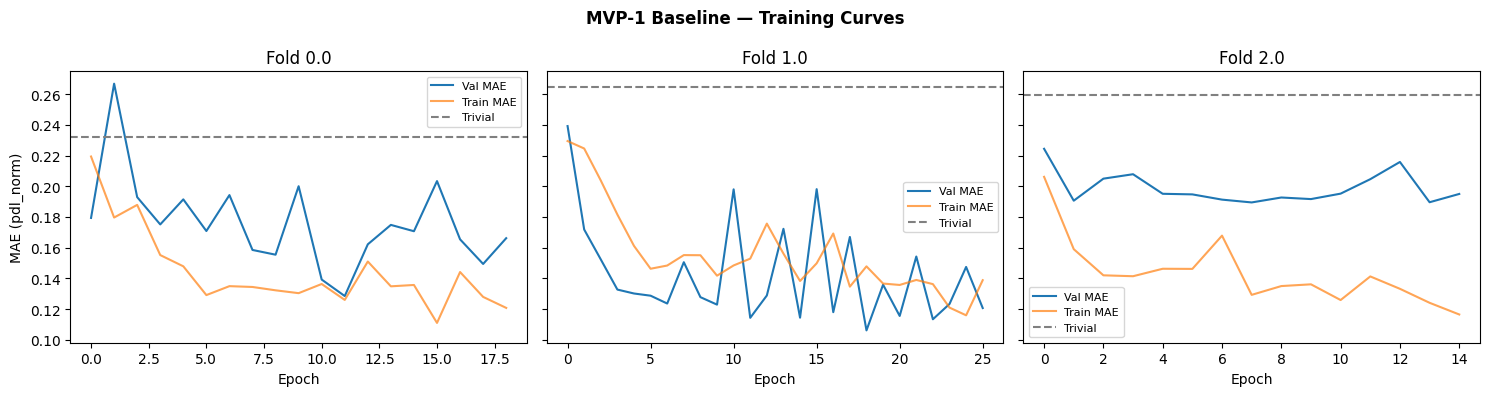

📈 Guardado: training_curves.png


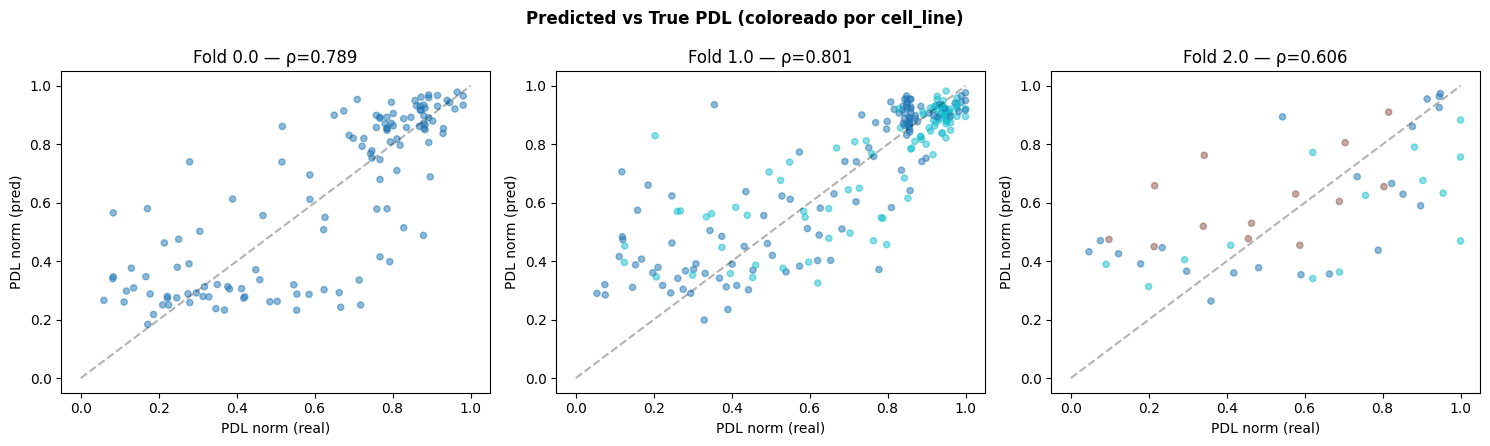

📈 Guardado: pred_vs_true.png


In [41]:
print("\n" + "=" * 70)
print("  RESUMEN MVP-1 BASELINE — 3-FOLD CV")
print("=" * 70)

rows = []
for fold, r in results_per_fold.items():
    rows.append({
        "Fold": fold,
        "N_val": r["n_val"],
        "Cell_lines": ", ".join(r["cell_lines_val"]),
        "MAE_trivial": f"{r['trivial_mae']:.4f}",
        "MAE_modelo": f"{r['model_mae']:.4f}",
        "Mejora%": f"{r['improvement_pct']:+.1f}%",
        "Spearman": f"{r['spearman']:.3f}",
        "R²": f"{r['r2']:.3f}",
    })

df_results = pd.DataFrame(rows)
print(df_results.to_string(index=False))

# Agregados
maes = [r["model_mae"] for r in results_per_fold.values()]
spears = [r["spearman"] for r in results_per_fold.values()]
imps = [r["improvement_pct"] for r in results_per_fold.values()]

print(f"\n  Promedio MAE (norm): {np.mean(maes):.4f} ± {np.std(maes):.4f}")
print(f"  Promedio Spearman:   {np.mean(spears):.3f} ± {np.std(spears):.3f}")
print(f"  Promedio mejora:     {np.mean(imps):+.1f}%")

# Criterio PIDA
pida_spearman = np.mean(spears) >= 0.6
pida_mejora = np.mean(imps) >= 25
print(f"\n  ✅ Spearman ≥ 0.6:   {'SÍ ✓' if pida_spearman else 'NO ✗'}  ({np.mean(spears):.3f})")
print(f"  ✅ Mejora ≥ 25%:     {'SÍ ✓' if pida_mejora else 'NO ✗'}  ({np.mean(imps):+.1f}%)")

# Guardar tabla
df_results.to_csv(os.path.join(OUTPUT_DIR, "results_3fold.csv"), index=False)

# --- Plot: training curves ---
fig, axes = plt.subplots(1, len(folds), figsize=(5 * len(folds), 4), sharey=True)
if len(folds) == 1:
    axes = [axes]
for ax, (fold, r) in zip(axes, results_per_fold.items()):
    ax.plot(r["history"]["val_mae"], label="Val MAE", color="tab:blue")
    ax.plot(r["history"]["train_loss"], label="Train MAE", color="tab:orange", alpha=0.7)
    ax.axhline(r["trivial_mae"], color="gray", linestyle="--", label="Trivial")
    ax.set_title(f"Fold {fold}")
    ax.set_xlabel("Epoch")
    ax.legend(fontsize=8)
axes[0].set_ylabel("MAE (pdl_norm)")
plt.suptitle("MVP-1 Baseline — Training Curves", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"📈 Guardado: training_curves.png")

# --- Plot: predicted vs true ---
fig, axes = plt.subplots(1, len(folds), figsize=(5 * len(folds), 4.5))
if len(folds) == 1:
    axes = [axes]
for ax, fold in zip(axes, folds):
    mask = df_embeddings[COL_FOLD] == fold
    y_t = df_embeddings.loc[mask, COL_PDL_NORM].values
    y_p = df_embeddings.loc[mask, "y_pred"].values
    ax.scatter(y_t, y_p, alpha=0.5, s=20,
               c=df_embeddings.loc[mask, COL_CELL_LINE].astype("category").cat.codes,
               cmap="tab10")
    ax.plot([0, 1], [0, 1], "k--", alpha=0.3)
    ax.set_xlabel("PDL norm (real)")
    ax.set_ylabel("PDL norm (pred)")
    ax.set_title(f"Fold {fold} — ρ={results_per_fold[fold]['spearman']:.3f}")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)
plt.suptitle("Predicted vs True PDL (coloreado por cell_line)", fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pred_vs_true.png"), dpi=150, bbox_inches="tight")
plt.show()
print(f"📈 Guardado: pred_vs_true.png")

## SECCIÓN 8 — BATCH PROBE
¿El embedding es detector de batch (fase/magnificación) o de biología?

Se entrena un clasificador simple sobre los embeddings para predecir
variables de adquisición. Si AUC >> 0.5, el embedding está contaminado.

In [42]:
emb_cols = [c for c in df_embeddings.columns if c.startswith("emb_")]
X_emb = df_embeddings[emb_cols].values

print("=" * 60)
print("  BATCH PROBE — ¿z_img captura batch o biología?")
print("=" * 60)

probe_results = {}

# --- Probe 1: study_part (fase) ---
if COL_STUDY_PART in df_embeddings.columns:
    y_sp = df_embeddings[COL_STUDY_PART].values
    n_classes = len(np.unique(y_sp))
    if n_classes >= 2:
        le = LabelEncoder()
        y_enc = le.fit_transform(y_sp)
        clf = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
        clf.fit(X_emb, y_enc)
        y_prob = clf.predict_proba(X_emb)
        acc = accuracy_score(y_enc, clf.predict(X_emb))
        if n_classes == 2:
            auc = roc_auc_score(y_enc, y_prob[:, 1])
        else:
            auc = roc_auc_score(y_enc, y_prob, multi_class="ovr", average="macro")
        probe_results["study_part"] = {"auc": auc, "acc": acc, "n_classes": n_classes}
        status = "⚠️ CONTAMINADO" if auc > 0.75 else "✅ OK"
        print(f"\n  Study_part (fase): AUC={auc:.3f}, Acc={acc:.3f} ({n_classes} clases) {status}")
    else:
        print(f"\n  Study_part: solo 1 clase — skip")

# --- Probe 2: magnification ---
if COL_MAGNIFICATION in df_embeddings.columns:
    y_mag = df_embeddings[COL_MAGNIFICATION].astype(str).values
    n_classes = len(np.unique(y_mag))
    if n_classes >= 2:
        le = LabelEncoder()
        y_enc = le.fit_transform(y_mag)
        clf = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
        clf.fit(X_emb, y_enc)
        y_prob = clf.predict_proba(X_emb)
        acc = accuracy_score(y_enc, clf.predict(X_emb))
        if n_classes == 2:
            auc = roc_auc_score(y_enc, y_prob[:, 1])
        else:
            auc = roc_auc_score(y_enc, y_prob, multi_class="ovr", average="macro")
        probe_results["magnification"] = {"auc": auc, "acc": acc, "n_classes": n_classes}
        status = "⚠️ CONTAMINADO" if auc > 0.75 else "✅ OK"
        print(f"  Magnification:    AUC={auc:.3f}, Acc={acc:.3f} ({n_classes} clases) {status}")
    else:
        print(f"  Magnification: solo 1 clase — skip")

# --- Probe 3: cell_line (identidad del donante) ---
y_cl = df_embeddings[COL_CELL_LINE].values
n_classes = len(np.unique(y_cl))
if n_classes >= 2:
    le = LabelEncoder()
    y_enc = le.fit_transform(y_cl)
    clf = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
    clf.fit(X_emb, y_enc)
    y_prob = clf.predict_proba(X_emb)
    acc = accuracy_score(y_enc, clf.predict(X_emb))
    auc = roc_auc_score(y_enc, y_prob, multi_class="ovr", average="macro")
    probe_results["cell_line"] = {"auc": auc, "acc": acc, "n_classes": n_classes}
    # cell_line AUC alta no es necesariamente malo (puede haber diferencias reales)
    # pero si es perfecta (>0.95), sugiere que el embedding memoriza donante
    status = "⚠️ MEMORIZANDO DONANTE" if auc > 0.95 else "📊 Revisar"
    print(f"  Cell_line:        AUC={auc:.3f}, Acc={acc:.3f} ({n_classes} clases) {status}")

# --- Probe 4: PDL bins (esto SÍ debería ser alto) ---
pdl_bins = pd.cut(df_embeddings[COL_PDL_NORM], bins=3, labels=["early", "mid", "late"])
le = LabelEncoder()
y_enc = le.fit_transform(pdl_bins)
clf = LogisticRegression(max_iter=1000, random_state=SEED, C=1.0)
clf.fit(X_emb, y_enc)
y_prob = clf.predict_proba(X_emb)
acc = accuracy_score(y_enc, clf.predict(X_emb))
auc = roc_auc_score(y_enc, y_prob, multi_class="ovr", average="macro")
probe_results["pdl_bins"] = {"auc": auc, "acc": acc, "n_classes": 3}
status = "✅ SEÑAL BIOLÓGICA" if auc > 0.65 else "⚠️ Embedding no captura PDL"
print(f"  PDL bins (e/m/l): AUC={auc:.3f}, Acc={acc:.3f} (3 clases)  {status}")

print(f"\n  📋 Interpretación:")
print(f"     - study_part/magnification ALTO → embedding captura artefactos de adquisición")
print(f"     - PDL bins ALTO → embedding captura señal biológica (bueno)")
print(f"     - cell_line MUY ALTO → posible memorización de donante (evaluar)")

# Guardar
with open(os.path.join(OUTPUT_DIR, "batch_probe.json"), "w") as f:
    json.dump(probe_results, f, indent=2)
print(f"\n💾 Guardado: batch_probe.json")

  BATCH PROBE — ¿z_img captura batch o biología?

  Study_part (fase): AUC=1.000, Acc=1.000 (4 clases) ⚠️ CONTAMINADO
  Magnification: solo 1 clase — skip
  Cell_line:        AUC=0.995, Acc=0.931 (6 clases) ⚠️ MEMORIZANDO DONANTE
  PDL bins (e/m/l): AUC=0.996, Acc=0.964 (3 clases)  ✅ SEÑAL BIOLÓGICA

  📋 Interpretación:
     - study_part/magnification ALTO → embedding captura artefactos de adquisición
     - PDL bins ALTO → embedding captura señal biológica (bueno)
     - cell_line MUY ALTO → posible memorización de donante (evaluar)

💾 Guardado: batch_probe.json


## SECCIÓN 9 — FUSION-READINESS
Correlación entre embedding promedio por muestra y biomarcadores
(telómero, mtDNA) del CSV central.

**Esto es lo que transforma MVP-1 de ejercicio técnico a contribución científica.**

  FUSION-READINESS — ¿z_img correlaciona con hallmarks?

CSV central: 1919 filas × 271 columnas
  Telómero col: telomere_length
  mtDNA col:    mtdna_cn
  Columnas ya presentes en manifest: ['telomere_length', 'mtdna_cn']

  Correlaciones embedding (PC1) vs biomarcadores:
  ──────────────────────────────────────────────────
  ⚠️ telomere_length                | ρ=-0.002 (p=9.86e-01) ns | n=85
  ⚠️ mtdna_cn                       | ρ=+0.128 (p=2.44e-01) ns | n=85
  📊 PDL norm (sanity check)        | ρ=+0.347 (p=1.54e-12)


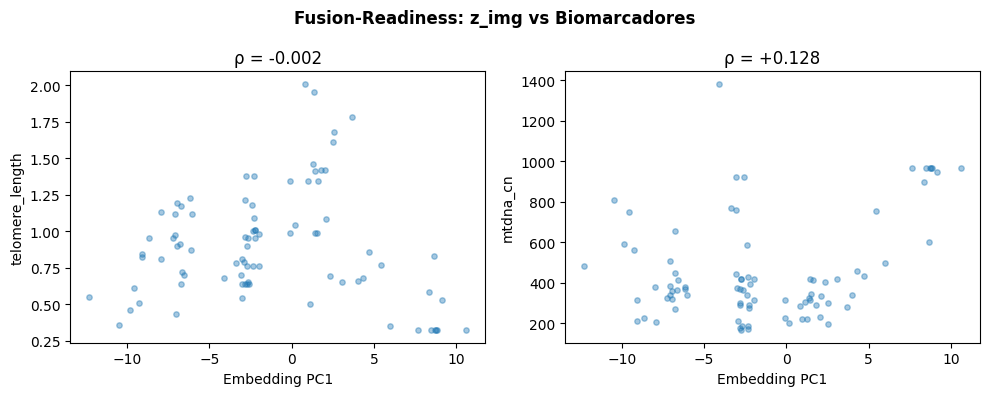

📈 Guardado: fusion_readiness.png
💾 Guardado: fusion_readiness.json


In [43]:
print("=" * 60)
print("  FUSION-READINESS — ¿z_img correlaciona con hallmarks?")
print("=" * 60)

# Cargar CSV central
df_csv = pd.read_csv(CSV_CENTRAL)
print(f"\nCSV central: {df_csv.shape[0]} filas × {df_csv.shape[1]} columnas")

# Autodetectar columnas de telómero y mtDNA
def find_column(df, keywords):
    """Busca columna cuyo nombre contenga alguna keyword (case-insensitive)."""
    for kw in keywords:
        matches = [c for c in df.columns if kw.lower() in c.lower()]
        if matches:
            return matches[0]
    return None

COL_TELOMERE = "telomere_length"
COL_MTDNA    = "mtdna_cn"

if COL_TELOMERE is None:
    COL_TELOMERE = find_column(df_csv, ["telomere", "telo", "TL_"])
if COL_MTDNA is None:
    COL_MTDNA = find_column(df_csv, ["mtdna", "mt_dna", "mtDNA", "mito_copy"])

print(f"  Telómero col: {COL_TELOMERE or '❌ NO ENCONTRADA'}")
print(f"  mtDNA col:    {COL_MTDNA or '❌ NO ENCONTRADA'}")

if COL_TELOMERE is None and COL_MTDNA is None:
    print("\n⚠️  No se encontraron columnas de telómero ni mtDNA automáticamente.")
    print("   Columnas disponibles con 'tel', 'mt', 'dna', 'copy':")
    candidates = [c for c in df_csv.columns
                  if any(kw in c.lower() for kw in ["tel", "mt", "dna", "copy", "mito"])]
    for c in candidates[:20]:
        print(f"     - {c}")
    print("\n   → Ajusta COL_TELOMERE y COL_MTDNA en CONFIG y re-ejecuta esta sección.")
else:
    # Hacer join con embeddings
    # Necesitamos una llave común. Intentamos sample_id primero, luego la quíntupla.
    fusion_cols = [c for c in [COL_TELOMERE, COL_MTDNA] if c is not None]

    if COL_SAMPLE_ID in df_embeddings.columns and COL_SAMPLE_ID in df_csv.columns:
        # Join por sample_id (ideal)
        df_join = df_embeddings.merge(
            df_csv[[COL_SAMPLE_ID] + fusion_cols].drop_duplicates(),
            on=COL_SAMPLE_ID, how="left", suffixes=("", "_csv")
        )
        print(f"  Join por sample_id: {df_join[fusion_cols[0]].notna().sum()}/{len(df_join)} con datos")
    else:
        # Fallback: las columnas ya están en el manifest (join previo)
        df_join = df_embeddings.copy()
        present = [c for c in fusion_cols if c in df_join.columns]
        if present:
            print(f"  Columnas ya presentes en manifest: {present}")
        else:
            print(f"  ⚠️ No hay llave de join disponible. Asegúrate de que el manifest")
            print(f"     incluya las columnas de biomarcadores del CSV central.")
            df_join = None

    if df_join is not None:
        # Embedding medio por imagen (ya es 1 embedding por imagen, así que directo)
        # Calcular primer componente principal del embedding como score resumen
        from sklearn.decomposition import PCA
        emb_matrix = df_join[emb_cols].values
        pca = PCA(n_components=1, random_state=SEED)
        df_join["emb_pc1"] = pca.fit_transform(emb_matrix)[:, 0]

        print(f"\n  Correlaciones embedding (PC1) vs biomarcadores:")
        print(f"  {'─' * 50}")

        fusion_results = {}
        for col in fusion_cols:
            if col in df_join.columns:
                mask = df_join[col].notna()
                n_valid = mask.sum()
                if n_valid >= 10:
                    rho, p_val = spearmanr(df_join.loc[mask, "emb_pc1"],
                                           df_join.loc[mask, col])
                    r_pearson, p_pearson = pearsonr(df_join.loc[mask, "emb_pc1"],
                                                     df_join.loc[mask, col])
                    fusion_results[col] = {
                        "spearman": rho, "spearman_p": p_val,
                        "pearson": r_pearson, "pearson_p": p_pearson,
                        "n": int(n_valid),
                    }
                    sig = "***" if p_val < 0.001 else "**" if p_val < 0.01 else "*" if p_val < 0.05 else "ns"
                    status = "✅" if abs(rho) > 0.1 and p_val < 0.05 else "⚠️"
                    print(f"  {status} {col:30s} | ρ={rho:+.3f} (p={p_val:.2e}) {sig} | n={n_valid}")
                else:
                    print(f"  ⚠️ {col:30s} | Solo {n_valid} datos — insuficiente")

        # También correlación con pdl_norm (sanity check)
        rho_pdl, p_pdl = spearmanr(df_join["emb_pc1"], df_join[COL_PDL_NORM])
        print(f"  📊 {'PDL norm (sanity check)':30s} | ρ={rho_pdl:+.3f} (p={p_pdl:.2e})")

        # Scatter plots
        plot_cols = [c for c in fusion_cols if c in df_join.columns and df_join[c].notna().sum() >= 10]
        if plot_cols:
            fig, axes = plt.subplots(1, len(plot_cols), figsize=(5 * len(plot_cols), 4))
            if len(plot_cols) == 1:
                axes = [axes]
            for ax, col in zip(axes, plot_cols):
                mask = df_join[col].notna()
                ax.scatter(df_join.loc[mask, "emb_pc1"], df_join.loc[mask, col],
                           alpha=0.4, s=15)
                rho = fusion_results[col]["spearman"]
                ax.set_xlabel("Embedding PC1")
                ax.set_ylabel(col)
                ax.set_title(f"ρ = {rho:+.3f}")
            plt.suptitle("Fusion-Readiness: z_img vs Biomarcadores", fontweight="bold")
            plt.tight_layout()
            plt.savefig(os.path.join(OUTPUT_DIR, "fusion_readiness.png"),
                        dpi=150, bbox_inches="tight")
            plt.show()
            print(f"📈 Guardado: fusion_readiness.png")

        # Guardar
        with open(os.path.join(OUTPUT_DIR, "fusion_readiness.json"), "w") as f:
            json.dump(fusion_results, f, indent=2, default=str)
        print(f"💾 Guardado: fusion_readiness.json")

In [44]:
# En las 164 muestras con biomarcadores:
mask = df_join['telomere_length'].notna()
sub = df_join[mask]

# ¿PDL y telómero correlacionan directamente?
rho_pdl_telo, p = spearmanr(sub['pdl_norm'], sub['telomere_length'])
rho_pdl_mt, p2 = spearmanr(sub['pdl_norm'], sub['mtdna_cn'])
print(f"PDL vs telomere: ρ={rho_pdl_telo:.3f}")
print(f"PDL vs mtDNA:    ρ={rho_pdl_mt:.3f}")

# Agregado por sample_id
agg = sub.groupby('sample_id').agg({
    'emb_pc1': 'mean',
    'pdl_norm': 'first',
    'telomere_length': 'first',
    'mtdna_cn': 'first'
})
rho1, p1 = spearmanr(agg['emb_pc1'], agg['telomere_length'])
rho2, p2 = spearmanr(agg['emb_pc1'], agg['mtdna_cn'])
print(f"\nAgregado por sample_id (n={len(agg)}):")
print(f"emb_pc1 vs telomere: ρ={rho1:.3f} (p={p1:.2e})")
print(f"emb_pc1 vs mtDNA:    ρ={rho2:.3f} (p={p2:.2e})")

PDL vs telomere: ρ=-0.801
PDL vs mtDNA:    ρ=0.759

Agregado por sample_id (n=77):
emb_pc1 vs telomere: ρ=0.207 (p=7.10e-02)
emb_pc1 vs mtDNA:    ρ=-0.033 (p=7.75e-01)


## SECCIÓN 10 — EXPORTAR EMBEDDINGS + REPORTE FINAL

In [45]:
# Guardar embeddings para uso posterior (UMAP, ablations, etc.)
emb_path = os.path.join(OUTPUT_DIR, "embeddings_finetune.csv")
df_embeddings.to_csv(emb_path, index=False)
print(f"💾 Embeddings guardados: {emb_path}")

# --- Reporte resumen ---
report = {
    "timestamp": datetime.now().isoformat(),
    "manifest": os.path.basename(MANIFEST_PATH),
    "n_images": len(df),
    "n_folds": len(folds),
    "model": "ResNet-34 (frozen) + head 256→PDL",
    "hyperparams": {
        "batch_size": BATCH_SIZE, "epochs": EPOCHS, "patience": PATIENCE,
        "lr": LR_HEAD, "weight_decay": WEIGHT_DECAY,
        "embedding_dim": EMBEDDING_DIM, "img_size": IMG_SIZE,
    },
    "results_per_fold": {
        str(k): {key: val for key, val in v.items() if key != "history"}
        for k, v in results_per_fold.items()
    },
    "aggregated": {
        "mean_mae_norm": float(np.mean(maes)),
        "std_mae_norm": float(np.std(maes)),
        "mean_spearman": float(np.mean(spears)),
        "std_spearman": float(np.std(spears)),
        "mean_improvement_pct": float(np.mean(imps)),
    },
    "batch_probe": probe_results,
    "pida_criteria": {
        "spearman_ge_0.6": bool(pida_spearman),
        "improvement_ge_25pct": bool(pida_mejora),
    },
}

report_path = os.path.join(OUTPUT_DIR, "mvp1_baseline_report.json")
with open(report_path, "w") as f:
    json.dump(report, f, indent=2, default=str)
print(f"💾 Reporte completo: {report_path}")

print(f"\n{'='*60}")
print(f"  MVP-1 BASELINE COMPLETO")
print(f"{'='*60}")
print(f"  Archivos generados en {OUTPUT_DIR}:")
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fsize = os.path.getsize(os.path.join(OUTPUT_DIR, fname))
    print(f"    {fname:40s} ({fsize/1024:.1f} KB)")

💾 Embeddings guardados: /Users/JCB/Documentos/Proyecto Integrador/results/mvp1_baseline/embeddings_finetune.csv
💾 Reporte completo: /Users/JCB/Documentos/Proyecto Integrador/results/mvp1_baseline/mvp1_baseline_report.json

  MVP-1 BASELINE COMPLETO
  Archivos generados en /Users/JCB/Documentos/Proyecto Integrador/results/mvp1_baseline:
    batch_probe.json                         (0.3 KB)
    best_model_fold0.0.pt                    (83861.5 KB)
    best_model_fold1.0.pt                    (83861.5 KB)
    best_model_fold2.0.pt                    (83861.5 KB)
    embeddings_finetune.csv                  (787.2 KB)
    fusion_readiness.json                    (0.4 KB)
    fusion_readiness.png                     (60.0 KB)
    mvp1_baseline_report.json                (2.0 KB)
    pred_vs_true.png                         (163.2 KB)
    results_3fold.csv                        (0.2 KB)
    training_curves.png                      (133.5 KB)


## SECCIÓN 11 — SIGUIENTE PASO: INTERPRETAR RESULTADOS

### ¿Qué hacer con estos números?

| Resultado | Acción |
|-----------|--------|
| Spearman ≥ 0.6 + batch probe bajo | ✅ Proceder a ablation (ranking + DANN) |
| Spearman < 0.4 + batch probe alto | ⚠️ Embedding captura batch, no biología → DANN urgente |
| Spearman < 0.4 + batch probe bajo | 🔍 Señal débil en brightfield → considerar pretrain con más datos |
| Fusion-readiness ρ > 0 significativo | ✅ Evidencia de que morfología captura hallmarks |
| Fusion-readiness ρ ≈ 0 | 📊 Normal en baseline; puede mejorar con fine-tuning |

### Próximo notebook: `mvp1_ablation.py`
- A1: MAE + ranking loss
- A2: MAE + ranking + consistency
- A3: + DANN (si batch probe muestra contaminación)

NameError: name 'batch_probe' is not defined